In [35]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv, find_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import RemoveMessage

In [36]:
load_dotenv(find_dotenv())

True

In [37]:
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [38]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    # Must always write to messages for MessagesState.
    return {"messages": []}

In [39]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [40]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [41]:
graph = builder.compile(checkpointer=InMemorySaver())

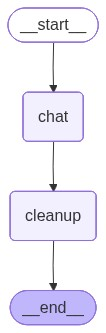

In [42]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # Fallback to Mermaid text if PNG rendering is unavailable.
    print(graph.get_graph().draw_mermaid())

In [43]:
config = {"configurable": {"thread_id": "t1"}}

In [44]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Parveen"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

C:\Users\saroh\AppData\Local\Temp\ipykernel_24112\3078041544.py:11: LangChainBetaWarning: The class `RemoveMessage` is in beta. It is actively being worked on, so the API may change.
  return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}


{'messages': [HumanMessage(content='What is Langchain', id='62ce802b-e6a7-44fa-a527-1ed61cbeffc6'),
  AIMessage(content='Hello Parveen! Great question – it\'s essential to understand LangChain before diving deep into LangGraph, as LangGraph builds directly on top of it.\n\n---\n\n### What is LangChain?\n\n**LangChain is a popular open-source framework (primarily in Python and JavaScript) designed to simplify the development of applications powered by large language models (LLMs).**\n\nIts core idea is to make it easier to **"chain"** together different components – such as LLMs, prompt templates, external data sources, and other tools – to create more complex, intelligent, and useful applications.\n\n### Why was LangChain created? (The Problem it Solves)\n\nWhile LLMs like GPT-4 are incredibly powerful, they are essentially just very sophisticated text prediction engines. To build truly useful applications with them, you often need to:\n\n1.  **Connect them to external data:** LLMs hav

In [45]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 6
